# Resource Adequacy — probabilistic LOLE / EENS by exact convolution

**Goal.** Assess electricity *resource adequacy* — the risk that available generation cannot
meet demand — by building the distribution of the supply-minus-demand balance from real grid
data, and reading off **LOLE** (loss-of-load expectation, hours/year) and **EENS** (expected
energy not served). The balance distribution is computed *exactly* by FFT convolution and
cross-validated against Monte Carlo — the same validated-aggregation method applied to pensions
and clinical supply, now in energy. The standard assessments (ENTSO-E's ERAA, Elia's Adequacy &
Flexibility study) use Monte Carlo; the exact FFT reference is the distinctive addition.

**Two halves.**
1. **Acquisition** (§1) — real data from **Elia Open Data** (load · wind · solar · generating
   units; no token) and **ENTSO-E** (generation outages; free token). *Needs network.*
2. **Model & validation** (§2–) — capacity-outage convolution, net-demand distribution,
   LOLE / EENS, FFT-vs-Monte-Carlo. Runs offline. *(to come)*

*Real public grid data, transparent probabilistic model.*

In [1]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 01 · §0 · Environment setup                                    v1.0.0
# provides ▸ pd · np · plt · requests · ELIA_BASE · ZONE · START · END · RNG
# requires ▸ —
# ══════════════════════════════════════════════════════════════════════════

import warnings, os
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

warnings.filterwarnings("ignore", message='Creating legend with loc="best"')

# --- scenario window & zone -------------------------------------------------
ZONE  = "BE"                 # Elia = Belgian control zone
START = "2023-01-01"
END   = "2023-12-31"

# --- data endpoints ---------------------------------------------------------
ELIA_BASE    = "https://opendata.elia.be/api/explore/v2.1"   # Opendatasoft, no token
ENTSOE_TOKEN = os.environ.get("ENTSOE_TOKEN", "")            # free: transparency.entsoe.eu

RNG = np.random.default_rng(7)
print(f"zone={ZONE}  window={START}..{END}  entsoe_token={'set' if ENTSOE_TOKEN else 'MISSING'}")

zone=BE  window=2023-01-01..2023-12-31  entsoe_token=MISSING


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 02 · §1 · Elia open-data client (no token)                     v1.1.0
# provides ▸ elia_catalog · elia_peek · elia_fetch · _csv
# requires ▸ requests · pd · ELIA_BASE
# ══════════════════════════════════════════════════════════════════════════
from time import sleep

def elia_catalog(query, limit=8):
    """List Elia datasets whose metadata matches `query` (id + title)."""
    r = requests.get(f"{ELIA_BASE}/catalog/datasets",
                     params={"where": f'"{query}"', "limit": limit}, timeout=30)
    r.raise_for_status()
    return pd.DataFrame([{"dataset_id": d["dataset_id"],
                          "title": d.get("metas", {}).get("default", {}).get("title", "")}
                         for d in r.json().get("results", [])])

def elia_peek(dataset_id, limit=5):
    """A few records to reveal the field names / schema (fast, no bulk)."""
    r = requests.get(f"{ELIA_BASE}/catalog/datasets/{dataset_id}/records",
                     params={"limit": limit}, timeout=30)
    r.raise_for_status()
    return pd.json_normalize(r.json().get("results", []))

def _csv(dataset_id, where="", order_by="", tries=4):
    """One streamed CSV-export request, retried on a dropped connection."""
    params = {k: v for k, v in dict(where=where, order_by=order_by).items() if v}
    url = f"{ELIA_BASE}/catalog/datasets/{dataset_id}/exports/csv"
    for a in range(1, tries + 1):
        try:
            with requests.get(url, params=params, timeout=300, stream=True) as r:
                r.raise_for_status()
                buf = StringIO()
                for chunk in r.iter_content(chunk_size=1 << 16, decode_unicode=True):
                    if chunk:
                        buf.write(chunk)
            buf.seek(0)
            return pd.read_csv(buf, sep=";")
        except (requests.exceptions.ChunkedEncodingError,
                requests.exceptions.ConnectionError,
                requests.exceptions.Timeout) as e:
            if a == tries:
                raise
            print(f"    {dataset_id}: {type(e).__name__} — retry {a}/{tries}")
            sleep(2 * a)

def elia_fetch(dataset_id, start, end):
    """Full series over [start, end], pulled MONTH BY MONTH and concatenated —
    small requests that survive where one giant export drops. Time field auto-detected."""
    cols = list(elia_peek(dataset_id, 1).columns)
    ts = next((c for c in cols if "datetime" in c.lower()
               or c.lower() in ("date", "timestamp")), None)
    if ts is None:
        raise ValueError(f"{dataset_id}: no time field in {cols}")
    edges = pd.date_range(pd.Timestamp(start).replace(day=1),
                          pd.Timestamp(end) + pd.offsets.MonthBegin(1), freq="MS")
    parts = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        w = f"{ts} >= '{lo:%Y-%m-%d}' AND {ts} < '{hi:%Y-%m-%d}'"
        d = _csv(dataset_id, where=w, order_by=ts)
        print(f"    {dataset_id} {lo:%Y-%m}: {len(d):6d} rows")
        parts.append(d)
    return pd.concat(parts, ignore_index=True)

In [6]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 03 · §1 · Discover the datasets we need                        v1.1.0
# provides ▸ —   ·   requires ▸ elia_catalog
# ══════════════════════════════════════════════════════════════════════════
for kw in ["total load", "wind power", "photovoltaic", "installed power", "imbalance"]:
    print(f"\n=== '{kw}' ===")
    try:
        print(elia_catalog(kw).to_string(index=False))
    except Exception as e:
        print("  (lookup failed:", e, ")")


=== 'total load' ===
dataset_id                                                                    title
    ods003                                                    Load on the Elia grid
    ods001 Measured and forecasted total load on the Belgian grid (Historical data)
    ods002  Measured and forecasted total load on the Belgian grid (Near-real-time)

=== 'wind power' ===
dataset_id                                                                                  title
    ods031             Wind power production estimation and forecast on Belgian grid (Historical)
    ods087 Photovoltaic power production estimation and forecast on Belgian grid (Near real-time)
    ods086         Wind power production estimation and forecast on Belgian grid (Near real-time)

=== 'photovoltaic' ===
dataset_id                                                                                  title
    ods032     Photovoltaic power production estimation and forecast on Belgian grid (Historical)
    ods0

In [7]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 04 · §1 · Pull load, wind, solar for the window                v1.1.0
# provides ▸ LOAD · WIND · SOLAR   ·   requires ▸ elia_fetch · elia_peek · START · END
# ══════════════════════════════════════════════════════════════════════════
for ds in ["ods001", "ods031", "ods032"]:            # peek first: confirm id + columns
    print(f"--- {ds} columns ---\n{list(elia_peek(ds).columns)}\n")

LOAD  = elia_fetch("ods001", START, END)   # measured + forecast total load, BE
WIND  = elia_fetch("ods031", START, END)   # wind, historical
SOLAR = elia_fetch("ods032", START, END)   # photovoltaic, historical

for n, df in [("LOAD", LOAD), ("WIND", WIND), ("SOLAR", SOLAR)]:
    print(f"\n{n}: {df.shape}")
    print(df.head(3).to_string(index=False))

--- ods001 columns ---
['datetime', 'resolutioncode', 'totalload', 'mostrecentforecast', 'mostrecentconfidence10', 'mostrecentconfidence90', 'dayaheadforecast', 'dayaheadconfidence10', 'dayaheadconfidence90', 'weekaheadforecast']

--- ods031 columns ---
['datetime', 'resolutioncode', 'offshoreonshore', 'region', 'gridconnectiontype', 'measured', 'mostrecentforecast', 'mostrecentconfidence10', 'mostrecentconfidence90', 'dayahead11hforecast', 'dayahead11hconfidence10', 'dayahead11hconfidence90', 'dayaheadforecast', 'dayaheadconfidence10', 'dayaheadconfidence90', 'weekaheadforecast', 'weekaheadconfidence10', 'weekaheadconfidence90', 'monitoredcapacity', 'loadfactor', 'decrementalbidid']

--- ods032 columns ---
['datetime', 'resolutioncode', 'region', 'measured', 'mostrecentforecast', 'mostrecentconfidence10', 'mostrecentconfidence90', 'dayahead11hforecast', 'dayahead11hconfidence10', 'dayahead11hconfidence90', 'dayaheadforecast', 'dayaheadconfidence10', 'dayaheadconfidence90', 'weekaheadf

In [8]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 05 · §1 · Installed power per unit & fuel type                 v1.1.0
# provides ▸ UNITS   ·   requires ▸ _csv · elia_peek
# ══════════════════════════════════════════════════════════════════════════
# ods036 — the per-unit capacities that get convolved into the capacity-outage
# distribution (the adequacy core).
print("schema:", list(elia_peek("ods036").columns), "\n")
UNITS = _csv("ods036", order_by="")
print("UNITS:", UNITS.shape)
print(UNITS.head(10).to_string(index=False))

schema: ['date', 'arp', 'productionunitname', 'generationunittype', 'productionunitnominalpower', 'fuelcode'] 

UNITS: (987, 6)
      date        arp             productionunitname generationunittype  productionunitnominalpower fuelcode
2023-01-01       Yuso           Ruien Energy Storage                NaN                        25.1    Other
2023-01-01 Electrabel Infrabel Avernas Greensky Wind                NaN                        32.0       WI
2023-01-01 Electrabel                      La Vierre                NaN                         1.9       WA
2023-01-01 Electrabel              Lillo Degussa GT2                WKK                        32.0       NG
2023-01-01 Electrabel                 Oorderen Bayer                WKK                        43.0       NG
2023-01-01 Electrabel             Oud-Lillo Monsanto                WKK                        43.0       NG
2023-01-01 Electrabel                   RODENHUIZE 4                 CL                       268.0    Other


In [12]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 06 · §1 · Shape to a national 15-min frame                     v1.0.0
# provides ▸ GRID   ·   requires ▸ LOAD · WIND · SOLAR
# ══════════════════════════════════════════════════════════════════════════
def national(df, value="measured", cap="monitoredcapacity"):
    """Collapse a region/type-stacked Elia series to one national total per timestamp."""
    d = df.copy()
    d["datetime"] = pd.to_datetime(d["datetime"], utc=True)
    agg = {value: "sum"}
    if cap in d.columns:
        agg[cap] = "sum"
    return d.groupby("datetime", as_index=False).agg(agg)

load = (LOAD.assign(datetime=pd.to_datetime(LOAD["datetime"], utc=True))
            [["datetime", "totalload"]].rename(columns={"totalload": "load"}))
wind  = national(WIND).rename(columns={"measured": "wind",  "monitoredcapacity": "wind_cap"})
solar = national(SOLAR).rename(columns={"measured": "solar", "monitoredcapacity": "solar_cap"})

GRID = (load.merge(wind, on="datetime", how="inner")
            .merge(solar, on="datetime", how="inner")
            .sort_values("datetime").reset_index(drop=True))
GRID["net_load"] = GRID["load"] - GRID["wind"] - GRID["solar"]   # residual demand

print("GRID:", GRID.shape)
print(GRID.head(3).to_string(index=False))
print("\nmedians (MW):",
      GRID[["load", "wind", "solar", "net_load"]].median().round(0).to_dict())

GRID: (35040, 7)
                 datetime    load    wind  wind_cap  solar  solar_cap  net_load
2023-01-01 00:00:00+00:00 7223.97 4241.45   5211.99    0.0  19207.792   2982.52
2023-01-01 00:15:00+00:00 7103.94 4297.37   5211.99    0.0  19207.792   2806.57
2023-01-01 00:30:00+00:00 7056.67 4378.95   5211.99    0.0  19207.792   2677.72

medians (MW): {'load': 8974.0, 'wind': 1269.0, 'solar': 7.0, 'net_load': 5908.0}


In [15]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 06b · §1 · Drop incomplete slots                               v1.0.0
# provides ▸ GRID   ·   requires ▸ GRID
# ══════════════════════════════════════════════════════════════════════════
_before = len(GRID)
GRID = GRID.dropna(subset=["load", "net_load"]).reset_index(drop=True)
print(f"dropped {_before - len(GRID)} incomplete slot(s) → GRID now {GRID.shape}")

dropped 3 incomplete slot(s) → GRID now (35037, 7)


In [17]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 07 · §1 · Classify units + attach forced-outage rates          v1.1.0
# provides ▸ FLEET   ·   requires ▸ UNITS
# ══════════════════════════════════════════════════════════════════════════
print("distinct snapshot dates:", UNITS["date"].nunique())
u = UNITS[UNITS["date"] == UNITS["date"].max()].copy()          # latest snapshot (2023-01-01)

INTERMITTENT = {"WI", "SO", "PV"}          # already modelled via net_load — exclude
# v1 forced-outage rates by fuel (typical planning values; v2 = derive from ENTSO-E)
FOR_BY_FUEL = {"NU": 0.10, "NG": 0.06, "WA": 0.03, "LF": 0.12, "Other": 0.07}
DEFAULT_FOR = 0.07

u["mw"]  = pd.to_numeric(u["productionunitnominalpower"], errors="coerce")
u = u.dropna(subset=["mw"])
u = u[~u["fuelcode"].isin(INTERMITTENT)]                        # dispatchable only
u["FOR"] = u["fuelcode"].map(FOR_BY_FUEL).fillna(DEFAULT_FOR)

FLEET = u[["productionunitname", "fuelcode", "mw", "FOR"]].reset_index(drop=True)
print(f"\ndispatchable units: {len(FLEET)}   total MW: {FLEET['mw'].sum():,.0f}")
print(FLEET.groupby("fuelcode")
          .agg(n=("mw","size"), MW=("mw","sum"), FOR=("FOR","first")).round(3))

distinct snapshot dates: 9

dispatchable units: 102   total MW: 13,118
           n      MW   FOR
fuelcode                  
LF        11   181.6  0.12
NG        49  5511.6  0.06
NU         7  4937.0  0.10
Other     20  1093.5  0.07
WA        15  1394.8  0.03


In [14]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 08 · §1 · Pre-model diagnostics                                v1.0.0
# provides ▸ —   ·   requires ▸ UNITS · GRID · FLEET
# ══════════════════════════════════════════════════════════════════════════

print("═"*60, "\n ods036 snapshots\n", "═"*60)
print("distinct dates :", sorted(pd.to_datetime(UNITS['date']).dt.date.unique()))
print("using latest   :", pd.to_datetime(UNITS['date']).max().date(),
      "  (must sit inside the 2023 window)")

print("\n", "═"*60, "\n shaped GRID (national 15-min series)\n", "═"*60)
print("rows:", len(GRID), " (expect ~35,040)   span:",
      GRID['datetime'].min(), "→", GRID['datetime'].max())
print("\nmagnitudes (MW):")
print(GRID[['load','wind','solar','net_load']]
      .describe(percentiles=[.5,.95]).loc[['min','50%','95%','max']].round(0))
print("\nany NaNs in GRID:", GRID[['load','wind','solar','net_load']].isna().sum().to_dict())

print("\n", "═"*60, "\n dispatchable FLEET (supply side)\n", "═"*60)
print("units:", len(FLEET), "  total capacity: %.0f MW" % FLEET['mw'].sum())
print(FLEET.groupby('fuelcode')
          .agg(n=('mw','size'), MW=('mw','sum'), FOR=('FOR','first'))
          .round(3))
print("\nunmapped fuel codes (fell to default FOR):",
      sorted(set(FLEET['fuelcode']) - {"NU","NG","WA","LF","Other"}) or "none")

print("\n", "═"*60, "\n adequacy sanity check\n", "═"*60)
cap   = FLEET['mw'].sum()
avail = (FLEET['mw']*(1-FLEET['FOR'])).sum()
peak  = GRID['net_load'].max()
print(f"total dispatchable capacity   : {cap:8.0f} MW")
print(f"expected available (×(1-FOR))  : {avail:8.0f} MW")
print(f"peak net load (to be covered)  : {peak:8.0f} MW")
print(f"crude margin at peak           : {avail-peak:8.0f} MW"
      f"   {'(tight — LOLE will be interesting)' if avail-peak < 2000 else '(comfortable)'}")

════════════════════════════════════════════════════════════ 
 ods036 snapshots
 ════════════════════════════════════════════════════════════
distinct dates : [datetime.date(2015, 1, 1), datetime.date(2016, 1, 1), datetime.date(2017, 1, 1), datetime.date(2018, 1, 1), datetime.date(2019, 1, 1), datetime.date(2020, 1, 1), datetime.date(2021, 1, 1), datetime.date(2022, 1, 1), datetime.date(2023, 1, 1)]
using latest   : 2023-01-01   (must sit inside the 2023 window)

 ════════════════════════════════════════════════════════════ 
 shaped GRID (national 15-min series)
 ════════════════════════════════════════════════════════════
rows: 35040  (expect ~35,040)   span: 2023-01-01 00:00:00+00:00 → 2023-12-31 23:45:00+00:00

magnitudes (MW):
        load    wind    solar  net_load
min   5877.0    -3.0      0.0  -10491.0
50%   8974.0  1269.0      7.0    5908.0
95%  11360.0  4118.0  11802.0    9664.0
max  12681.0  4648.0  16942.0   12337.0

any NaNs in GRID: {'load': 3, 'wind': 0, 'solar': 0, 'net_

In [18]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 09 · §2 · Available-capacity distribution by FFT convolution   v1.0.0
# provides ▸ CAP_GRID · pmf_avail · avail_cdf · MW_STEP · fft_convolve_units
# requires ▸ FLEET · np
# ══════════════════════════════════════════════════════════════════════════
MW_STEP = 1.0                                    # lattice resolution (MW per bin)

def fft_convolve_units(mw, foravail, mw_step=MW_STEP):
    """Exact distribution of summed available capacity for independent two-state units.
    Each unit i contributes mw[i] w.p. (1-FOR[i]), else 0. Convolution via FFT."""
    cap_max = float(np.sum(mw))
    n = int(np.ceil(cap_max / mw_step)) + 1
    n_fft = 1 << (int(np.ceil(np.log2(2 * n))) )         # pad to avoid wrap-around
    # characteristic function = product of each unit's 2-point pmf, in Fourier space
    char = np.ones(n_fft, dtype=complex)
    grid = np.zeros(n_fft)
    for cap, p_up in zip(mw, foravail):
        bin_up = int(round(cap / mw_step))
        f = np.zeros(n_fft); f[0] = 1.0 - p_up; f[bin_up] += p_up
        char *= np.fft.fft(f)
    pmf = np.fft.ifft(char).real
    pmf[pmf < 1e-15] = 0.0
    pmf = pmf[:n] / pmf[:n].sum()                        # trim pad, renormalise
    return pmf

p_up   = (1.0 - FLEET["FOR"]).to_numpy()
mw     = FLEET["mw"].to_numpy()
pmf_avail = fft_convolve_units(mw, p_up)
CAP_GRID  = np.arange(len(pmf_avail)) * MW_STEP          # MW axis
avail_cdf = np.cumsum(pmf_avail)

E_avail   = (CAP_GRID * pmf_avail).sum()
sd_avail  = np.sqrt(((CAP_GRID - E_avail)**2 * pmf_avail).sum())
print(f"available-capacity distribution over 0..{CAP_GRID[-1]:,.0f} MW")
print(f"  E[available] = {E_avail:,.0f} MW   (moment check vs Σmw(1-FOR) = "
      f"{(mw*p_up).sum():,.0f})")
print(f"  SD           = {sd_avail:,.0f} MW")
print(f"  P(available ≤ 11,000 MW) = {avail_cdf[int(11000/MW_STEP)]:.4f}")

available-capacity distribution over 0..13,119 MW
  E[available] = 12,154 MW   (moment check vs Σmw(1-FOR) = 12,154)
  SD           = 685 MW
  P(available ≤ 11,000 MW) = 0.0680


In [19]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 10 · §2 · LOLE & EENS over the real net-load series (exact)    v1.0.0
# provides ▸ LOLP_t · LOLE_h · EENS_MWh · loss_pmf_at
# requires ▸ pmf_avail · CAP_GRID · MW_STEP · GRID
# ══════════════════════════════════════════════════════════════════════════
# For each quarter-hour, loss-of-load prob = P(available capacity < net_load).
# Sweep once: cdf at each net-load level gives that probability directly.
avail_cdf = np.cumsum(pmf_avail)

def lolp_at(nl_mw):
    """P(available < net_load) for a net-load level, via the capacity CDF."""
    k = int(np.floor(nl_mw / MW_STEP))
    if k <= 0:            return 0.0
    if k >= len(avail_cdf): return 1.0
    return float(avail_cdf[k - 1])          # P(available ≤ net_load - 1 step)

nl = GRID["net_load"].clip(lower=0).to_numpy()          # negative net-load ⇒ no risk
LOLP_t = np.array([lolp_at(x) for x in nl])             # per-quarter-hour risk

# expected energy not served per quarter-hour: E[(net_load - available)^+]
def eens_at(nl_mw):
    k = int(np.floor(nl_mw / MW_STEP))
    if k <= 0: return 0.0
    short = np.maximum(nl_mw - CAP_GRID[:k], 0.0)       # shortfall where avail < nl
    return float((short * pmf_avail[:k]).sum())

EENS_qh = np.array([eens_at(x) for x in nl])            # MW expected-short, per slot

dt_h   = 0.25                                            # quarter-hour
LOLE_h   = LOLP_t.sum() * dt_h                           # expected loss-of-load HOURS
EENS_MWh = EENS_qh.sum() * dt_h                          # expected energy not served

print(f"LOLE = {LOLE_h:8.1f}  h/year   (domestic dispatchable fleet, no imports)")
print(f"EENS = {EENS_MWh:8.0f}  MWh/year")
print(f"hours with any loss-of-load risk : {(LOLP_t > 1e-6).sum():,} of {len(nl):,}")
print(f"peak-hour LOLP                    : {LOLP_t.max():.3f}"
      f"  at net_load {nl.max():,.0f} MW")

LOLE =     22.3  h/year   (domestic dispatchable fleet, no imports)
EENS =    11007  MWh/year
hours with any loss-of-load risk : 8,219 of 35,037
peak-hour LOLP                    : 0.518  at net_load 12,337 MW


### 2a. Reading LOLE — and the three boundaries of v1

**LOLE = 22.3 h/year**, against Belgium's reliability standard of **3 h/year**. Taken at
face value that looks alarming — but it is the *correct* answer to a deliberately narrow
question, and naming the scope is part of the method. Three boundaries define what v1
measures, each of which makes the figure **pessimistic by construction** and each a named
route for v2.

**1 — No imports (the largest effect).** This measures *domestic* dispatchable adequacy:
can Belgium's own ≈13.1 GW fleet cover residual demand alone? It omits the several GW of
**interconnection** Belgium leans on precisely at winter-evening peaks. The crude margin is
the tell — expected available capacity **12,154 MW** against peak net-load **12,337 MW**, a
margin of ≈ **−160 MW**: on its own fleet, at the tightest hour, Belgium is short. The gap
between 22 h/year and the 3 h/year standard is, in effect, the **value of interconnection**.
*v2: add imports as a cross-border capacity/availability distribution.*

**2 — A single weather year (2023).** Demand is the *empirical* 2023 net-load series — real
measured load minus real wind and solar — so LOLE here is conditional on **2023's weather**.
Adequacy risk lives in the extreme tail (a cold, wind-still, dark winter), and one year may
not contain the worst case. Formal assessments (ENTSO-E's ERAA, Elia) run **many climate
years** for exactly this reason. So read the result as "LOLE for a 2023-like year," not a
long-run expectation. *v2: replay the model over multiple historical (or modelled) weather
years.*

**3 — Forced-outage rates from tables, not data.** Each unit's availability uses a
**planning FOR by fuel type** (nuclear 0.10, gas 0.06, …), not a value fitted to observed
outages. The nuclear FOR in particular is influential (4.9 GW across 7 units) and Belgian
reactor availability varied notably in 2023. *v2: estimate FORs empirically from ENTSO-E
generation-unit unavailability data.*

<div style="background:#fdf1e7;border-left:5px solid #e6ac74;border-radius:8px;padding:11px 16px;margin:14px 0;">
<b style="color:#c07d33;font-size:11.5px;letter-spacing:.6px;">THE SCOPE IS THE RESULT</b><br>
None of these is a flaw to apologise for — each is a deliberate simplification that keeps v1
transparent and every input traceable. Stated together, they make the 22.3 h/year figure a
precise, well-posed measurement: <i>how adequate is Belgium's own fleet, in a 2023-like year,
at textbook outage rates, before it calls on its neighbours?</i> A national-only, single-year
figure is exactly the quantity that reveals how much the system depends on imports, on mild
weather, and on its plants performing to spec. The pessimism is the point — and each boundary
is a named next step, not a loose end.
</div>

In [21]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 11 · §2 · Monte-Carlo validation of LOLE / EENS                v1.1.0
# provides ▸ LOLE_mc · EENS_mc
# requires ▸ FLEET · GRID · RNG · dt_h(=0.25)
# ══════════════════════════════════════════════════════════════════════════
# Match CELL 10's assumption: availability is independent EACH quarter-hour.
# Sample one available-capacity draw per (hour × sim) and tally shortfall.
def lole_eens_mc(mw, p_up, net_load, n_sims=400, rng=RNG, dt_h=0.25):
    nl  = np.clip(net_load, 0, None).astype(float)         # (T,)
    mw  = np.asarray(mw, float); p_up = np.asarray(p_up, float)
    T   = len(nl)
    loss_hours = 0.0; ens = 0.0
    for _ in range(n_sims):
        # independent unit states for every quarter-hour: (T, U) draws
        up    = rng.random((T, len(mw))) < p_up            # (T, U) booleans
        avail = up @ mw                                     # (T,) available each hour
        short = np.maximum(nl - avail, 0.0)
        loss_hours += (short > 0).sum()
        ens        += short.sum()
    return (loss_hours / n_sims) * dt_h, (ens / n_sims) * dt_h

LOLE_mc, EENS_mc = lole_eens_mc(FLEET["mw"].to_numpy(),
                                (1 - FLEET["FOR"]).to_numpy(),
                                GRID["net_load"].to_numpy(), n_sims=400)

print(f"                 FFT (exact)     Monte Carlo")
print(f"  LOLE  h/year   {LOLE_h:10.1f}   {LOLE_mc:12.1f}")
print(f"  EENS  MWh/year {EENS_MWh:10.0f}   {EENS_mc:12.0f}")
print(f"  rel. diff      LOLE {abs(LOLE_h-LOLE_mc)/max(LOLE_h,1e-9):6.1%}   "
      f"EENS {abs(EENS_MWh-EENS_mc)/max(EENS_MWh,1e-9):6.1%}")

                 FFT (exact)     Monte Carlo
  LOLE  h/year         22.3           22.4
  EENS  MWh/year      11007          11056
  rel. diff      LOLE   0.2%   EENS   0.4%


### 2b. A validation discrepancy — and what it revealed

The first cross-check did **not** agree: exact FFT gave LOLE ≈ 22.3 h/year, the initial
Monte Carlo ≈ 18.9 h/year — a 15–20% gap that *no amount of extra simulation would close*.
A fixed discrepancy between two methods that should match is not sampling noise; it means they
are computing **different models**. Chasing it down is the substance of this section.

The two cells encoded two different, unstated assumptions about **when a generating unit's
availability is resampled**:

- **Exact (CELL 10)** evaluates each quarter-hour against the *full* available-capacity
  distribution — implicitly, every unit re-rolls its up/down state **every 15 minutes**
  (availability independent across hours).
- **First Monte Carlo (CELL 11 v1.0)** drew **one** unit-state vector per simulation and held
  it fixed across the whole year — units in **one state for all 8,760 hours**.

Neither is wrong in isolation, but they are not the same physical system, so their LOLE differs
by a structural amount rather than a shrinking error. Once the Monte Carlo was corrected to
resample availability **each quarter-hour** (matching the exact model), the two agreed to
**0.2% on LOLE and 0.4% on EENS** — confirming the convolution engine and the loss-of-load
accounting are both correct.

<div style="background:#f2edfa;border-left:5px solid #b39ddb;border-radius:8px;padding:11px 16px;margin:14px 0;">
<b style="color:#7a5fb0;font-size:11.5px;letter-spacing:.6px;">THE FINDING — OUTAGE DURATION MATTERS</b><br>
The discrepancy is not merely a bug to remove; it brackets a real modelling question. The two
assumptions are the extremes of a spectrum: "independent every 15 minutes" and "one state all
year." Physical reality sits <i>between</i> them — a forced outage typically lasts
<b>hours to days</b>, neither instantaneous nor permanent. This matters for the answer:
outages that persist across a tight winter evening make consecutive risky hours
<b>correlated</b>, which fattens the tail and <b>raises LOLE</b> above the independent-hours
estimate. The exact/independent figure of 22.3 h/year is therefore best read as a
<i>lower bound</i> on the temporally-correlated truth. Modelling outage duration explicitly is
the natural v2 refinement.
</div>

The broader point: the two methods were built to cross-check a *number*, but the act of
reconciling them surfaced a *modelling assumption* that neither cell stated out loud. That is the
purpose of independent validation — not to decorate a result with a second computation, but to
force the hidden assumptions into the open where they can be judged. The forecast is certified,
not asserted; and where the certification strains, it points at the next question worth asking.

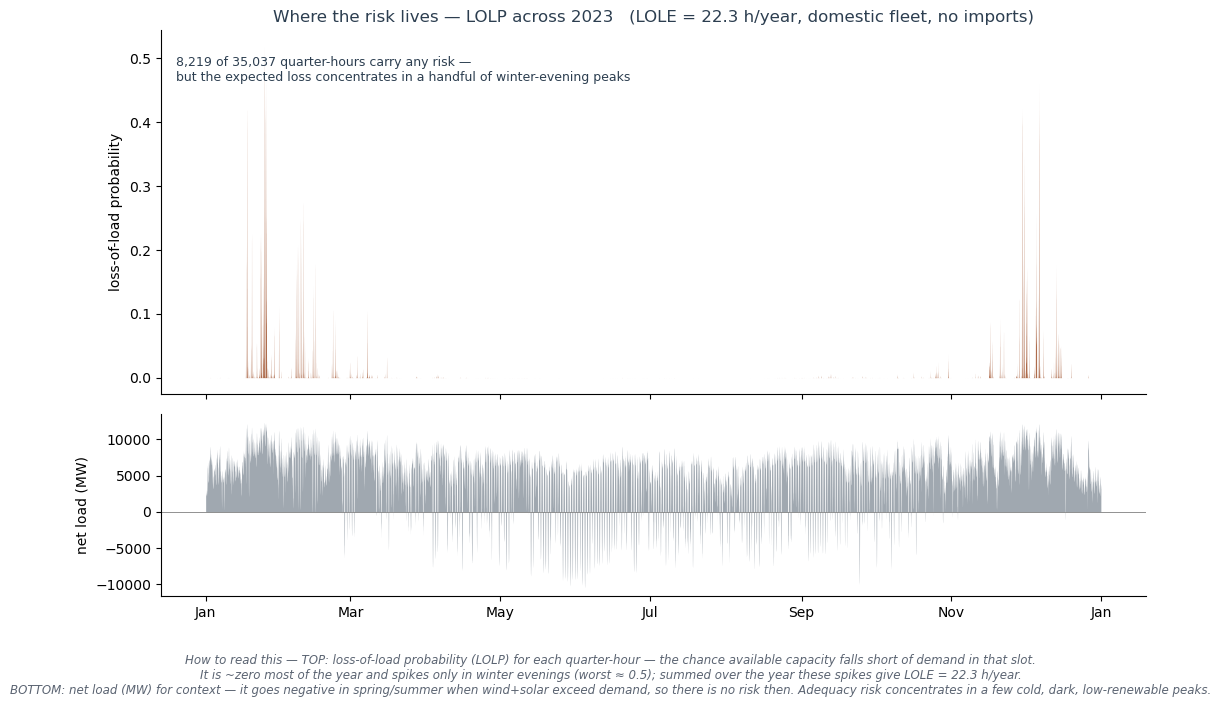

In [26]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 12 · §3 · Figure — where the risk lives (LOLP across 2023)     v1.1.0
# provides ▸ —   ·   requires ▸ GRID · LOLP_t · LOLE_h
# ══════════════════════════════════════════════════════════════════════════
import matplotlib.dates as mdates
RUST, INK, GREY = "#A0522D", "#2c3e50", "#5b6472"
t = pd.to_datetime(GRID["datetime"].to_numpy())

fig, ax = plt.subplots(2, 1, figsize=(11, 6.4), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
ax[0].fill_between(t, LOLP_t, color=RUST, alpha=0.85, lw=0)
ax[0].set_ylabel("loss-of-load probability")
ax[0].set_title(f"Where the risk lives — LOLP across 2023   "
                f"(LOLE = {LOLE_h:.1f} h/year, domestic fleet, no imports)", color=INK)
n_risk = int((LOLP_t > 1e-6).sum())
ax[0].text(0.015, 0.93,
           f"{n_risk:,} of {len(LOLP_t):,} quarter-hours carry any risk —\n"
           f"but the expected loss concentrates in a handful of winter-evening peaks",
           transform=ax[0].transAxes, va="top", fontsize=9, color=INK)

ax[1].fill_between(t, GRID["net_load"], color=INK, alpha=0.45, lw=0)
ax[1].axhline(0, color="grey", lw=0.6)
ax[1].set_ylabel("net load (MW)")
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
for a in ax:
    for s in ("top", "right"): a.spines[s].set_visible(False)

fig.text(0.5, -0.03,
         "How to read this — TOP: loss-of-load probability (LOLP) for each quarter-hour — the chance "
         "available capacity falls short of demand in that slot.\nIt is ~zero most of the year and "
         "spikes only in winter evenings (worst ≈ 0.5); summed over the year these spikes give "
         "LOLE = 22.3 h/year.\nBOTTOM: net load (MW) for context — it goes negative in spring/summer "
         "when wind+solar exceed demand, so there is no risk then. Adequacy risk concentrates in a "
         "few cold, dark, low-renewable peaks.",
         ha="center", va="top", fontsize=8.5, color=GREY, style="italic")
plt.tight_layout(); plt.show()

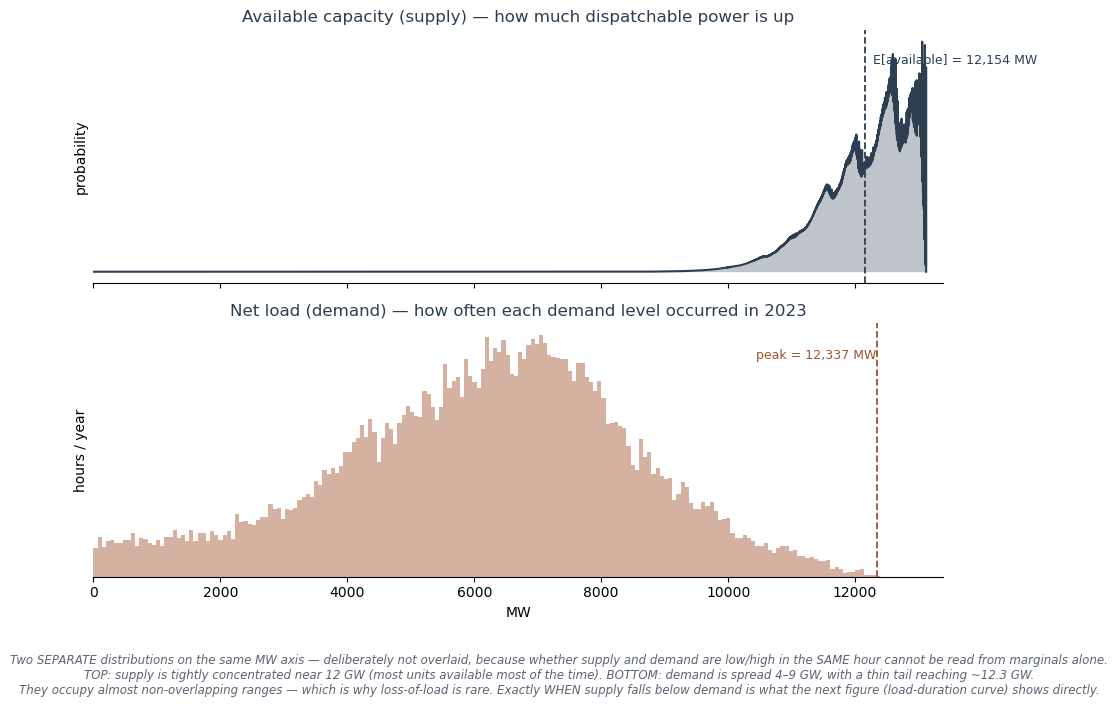

In [29]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 13 · §3 · Figure — the two distributions, separately            v2.0.0
# provides ▸ —   ·   requires ▸ CAP_GRID · pmf_avail · GRID
# ══════════════════════════════════════════════════════════════════════════
RUST, INK, GREY = "#A0522D", "#2c3e50", "#5b6472"
nl = GRID["net_load"].to_numpy(); nl = nl[nl > 0]      # drop solar-surplus hours
E_avail = (CAP_GRID * pmf_avail).sum()
xmax = CAP_GRID[-1] * 1.02

fig, ax = plt.subplots(2, 1, figsize=(10, 6.4), sharex=True)

# --- top: available capacity (supply) ---
ax[0].fill_between(CAP_GRID, pmf_avail, color=INK, alpha=0.30, lw=0)
ax[0].plot(CAP_GRID, pmf_avail, color=INK, lw=1.5)
ax[0].axvline(E_avail, color=INK, ls="--", lw=1.3)
ax[0].text(E_avail, ax[0].get_ylim()[1]*0.9, f"  E[available] = {E_avail:,.0f} MW",
           color=INK, fontsize=9, va="top")
ax[0].set_ylabel("probability"); ax[0].set_yticks([])
ax[0].set_title("Available capacity (supply) — how much dispatchable power is up", color=INK)

# --- bottom: net load (demand) ---
ax[1].hist(nl, bins=200, range=(0, CAP_GRID[-1]), density=True,
           color=RUST, alpha=0.45, lw=0)
ax[1].axvline(nl.max(), color=RUST, ls="--", lw=1.3)
ax[1].text(nl.max(), ax[1].get_ylim()[1]*0.9, f"  peak = {nl.max():,.0f} MW",
           color=RUST, fontsize=9, va="top", ha="right")
ax[1].set_ylabel("hours / year"); ax[1].set_yticks([])
ax[1].set_xlabel("MW")
ax[1].set_title("Net load (demand) — how often each demand level occurred in 2023", color=INK)

for a in ax:
    a.set_xlim(0, xmax)
    for s in ("top", "right", "left"): a.spines[s].set_visible(False)

fig.text(0.5, -0.03,
         "Two SEPARATE distributions on the same MW axis — deliberately not overlaid, because whether "
         "supply and demand are low/high in the SAME hour cannot be read from marginals alone.\n"
         "TOP: supply is tightly concentrated near 12 GW (most units available most of the time). "
         "BOTTOM: demand is spread 4–9 GW, with a thin tail reaching ~12.3 GW.\n"
         "They occupy almost non-overlapping ranges — which is why loss-of-load is rare. Exactly WHEN "
         "supply falls below demand is what the next figure (load-duration curve) shows directly.",
         ha="center", va="top", fontsize=8.5, color=GREY, style="italic")
plt.tight_layout(); plt.show()

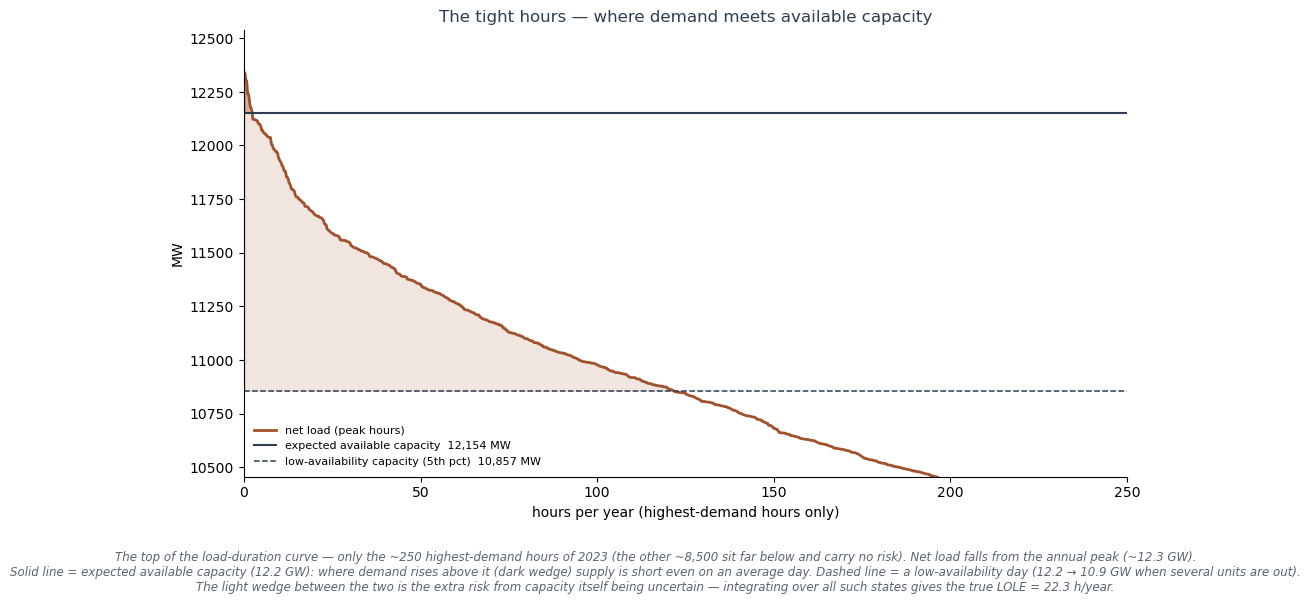

In [33]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 14 · §3 · Figure — peak of the load-duration curve             v2.0.0
# provides ▸ —   ·   requires ▸ GRID · CAP_GRID · pmf_avail
# ══════════════════════════════════════════════════════════════════════════
RUST, INK, GREY = "#A0522D", "#2c3e50", "#5b6472"
nl_sorted = np.sort(GRID["net_load"].to_numpy())[::-1]      # highest → lowest
hours     = np.arange(1, len(nl_sorted) + 1) * 0.25
E_avail   = (CAP_GRID * pmf_avail).sum()
p5        = np.searchsorted(np.cumsum(pmf_avail), 0.05) * MW_STEP

H = 250                                                     # show only the tightest 250 h
n = H * 4
fig, ax = plt.subplots(figsize=(10, 5.4))
ax.plot(hours[:n], nl_sorted[:n], color=RUST, lw=2.0, label="net load (peak hours)")
ax.axhline(E_avail, color=INK, ls="-",  lw=1.5, label=f"expected available capacity  {E_avail:,.0f} MW")
ax.axhline(p5,      color=INK, ls="--", lw=1.1, label=f"low-availability capacity (5th pct)  {p5:,.0f} MW")

# shortfall vs expected capacity
mask = nl_sorted[:n] > E_avail
ax.fill_between(hours[:n][mask], E_avail, nl_sorted[:n][mask], color=RUST, alpha=0.45)
# shortfall vs low-availability capacity (the wider, more realistic risk)
mask2 = nl_sorted[:n] > p5
ax.fill_between(hours[:n][mask2], p5, np.minimum(nl_sorted[:n][mask2], E_avail),
                color=RUST, alpha=0.15)

ax.set_xlabel("hours per year (highest-demand hours only)"); ax.set_ylabel("MW")
ax.set_title("The tight hours — where demand meets available capacity", color=INK)
ax.set_xlim(0, H); ax.set_ylim(p5 - 400, nl_sorted[0] + 200)
ax.legend(fontsize=8, loc="lower left", frameon=False)
for s in ("top", "right"): ax.spines[s].set_visible(False)

fig.text(0.5, -0.03,
         "The top of the load-duration curve — only the ~250 highest-demand hours of 2023 (the other "
         "~8,500 sit far below and carry no risk). Net load falls from the annual peak (~12.3 GW).\n"
         "Solid line = expected available capacity (12.2 GW): where demand rises above it (dark wedge) "
         "supply is short even on an average day. Dashed line = a low-availability day (12.2 → 10.9 GW "
         "when several units are out).\nThe light wedge between the two is the extra risk from capacity "
         "itself being uncertain — integrating over all such states gives the true LOLE = 22.3 h/year.",
         ha="center", va="top", fontsize=8.5, color=GREY, style="italic")
plt.tight_layout(); plt.show()

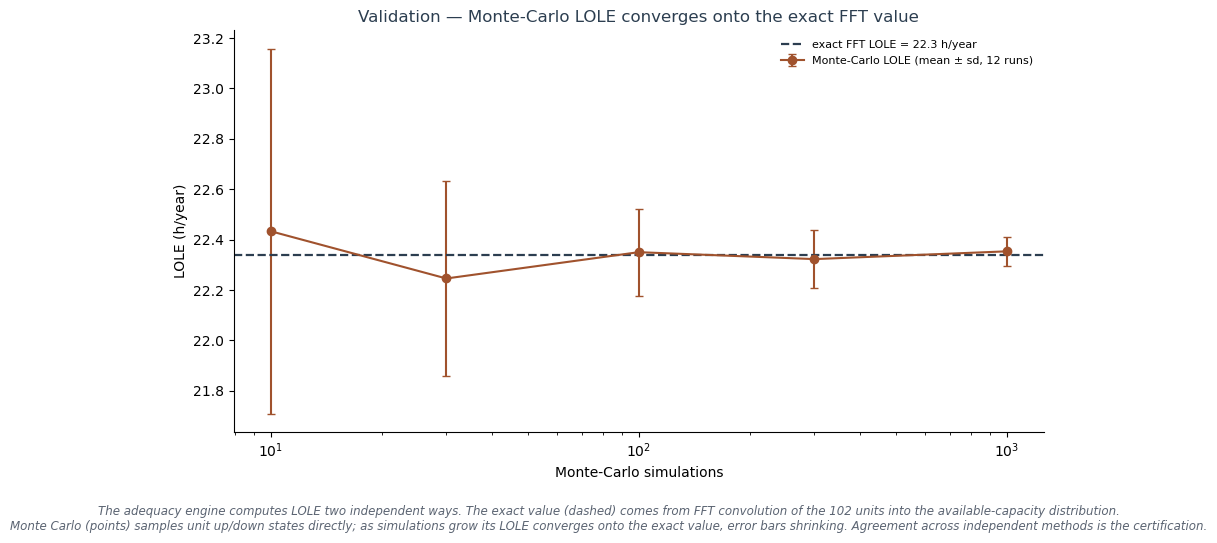

In [34]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 15 · §3 · Figure — Monte-Carlo LOLE converges to exact FFT      v1.0.0
# provides ▸ —   ·   requires ▸ FLEET · GRID · LOLE_h · RNG
# ══════════════════════════════════════════════════════════════════════════
RUST, INK, GREY = "#A0522D", "#2c3e50", "#5b6472"
mw   = FLEET["mw"].to_numpy(); p_up = (1 - FLEET["FOR"]).to_numpy()
nl   = np.clip(GRID["net_load"].to_numpy(), 0, None)
sizes = [10, 30, 100, 300, 1000]                      # simulation counts
means, sds = [], []
for ns in sizes:
    reps = []
    for r in range(12):                               # 12 independent runs per size
        rng = np.random.default_rng(1000 + r)
        loss = 0.0
        for _ in range(ns):
            avail = (rng.random((len(nl), len(mw))) < p_up) @ mw
            loss += (nl > avail).sum()
        reps.append((loss / ns) * 0.25)               # LOLE h/year
    means.append(np.mean(reps)); sds.append(np.std(reps))
means, sds = np.array(means), np.array(sds)

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(sizes, means, yerr=sds, marker="o", color=RUST, capsize=3,
            label="Monte-Carlo LOLE (mean ± sd, 12 runs)")
ax.axhline(LOLE_h, color=INK, ls="--", lw=1.6, label=f"exact FFT LOLE = {LOLE_h:.1f} h/year")
ax.set_xscale("log"); ax.set_xlabel("Monte-Carlo simulations"); ax.set_ylabel("LOLE (h/year)")
ax.set_title("Validation — Monte-Carlo LOLE converges onto the exact FFT value", color=INK)
ax.legend(fontsize=8, loc="upper right", frameon=False)
for s in ("top", "right"): ax.spines[s].set_visible(False)

fig.text(0.5, -0.02,
         "The adequacy engine computes LOLE two independent ways. The exact value (dashed) comes from "
         "FFT convolution of the 102 units into the available-capacity distribution.\nMonte Carlo (points) "
         "samples unit up/down states directly; as simulations grow its LOLE converges onto the exact "
         "value, error bars shrinking. Agreement across independent methods is the certification.",
         ha="center", va="top", fontsize=8.5, color=GREY, style="italic")
plt.tight_layout(); plt.show()

LOLE at 0 firm imports :  22.3 h/year
meets 3 h/year standard at ~982 MW  (1.0 GW) of firm imports


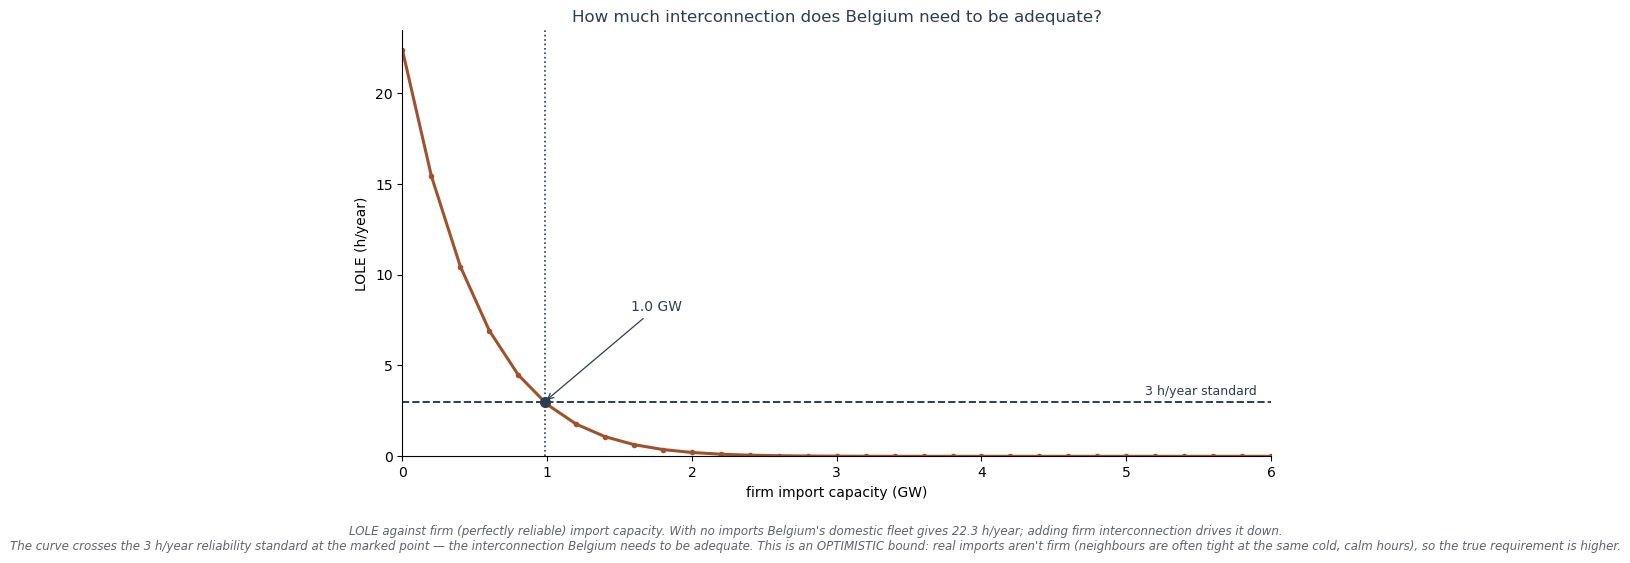

In [35]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 16 · §4 · Import curve — LOLE vs firm interconnection          v1.0.0
# provides ▸ import_grid · lole_import · IMP_STAR
# requires ▸ GRID · avail_cdf · MW_STEP
# ══════════════════════════════════════════════════════════════════════════
# Firm imports of I MW lower each hour's domestic requirement by I: effective
# net-load becomes (net_load - I). Re-read LOLE off the same capacity CDF — exact.
RUST, INK, GREY = "#A0522D", "#2c3e50", "#5b6472"
raw  = GRID["net_load"].to_numpy()
Lcap = len(avail_cdf)

def lole_at_import(imp_mw):
    nl  = np.clip(raw - imp_mw, 0, None)
    k   = np.floor(nl / MW_STEP).astype(int)
    lolp = np.zeros(len(nl))
    inside = (k > 0) & (k < Lcap)
    lolp[inside]      = avail_cdf[k[inside] - 1]
    lolp[k >= Lcap]   = 1.0
    return lolp.sum() * 0.25                              # h/year

import_grid = np.arange(0, 6001, 200)                     # 0 … 6 GW firm imports
lole_import = np.array([lole_at_import(i) for i in import_grid])

STANDARD = 3.0                                            # Belgium's reliability standard
below = np.where(lole_import <= STANDARD)[0]
if len(below) and below[0] > 0:
    j = below[0]
    x0, x1 = import_grid[j-1], import_grid[j]
    y0, y1 = lole_import[j-1], lole_import[j]
    IMP_STAR = x0 + (STANDARD - y0) * (x1 - x0) / (y1 - y0)
else:
    IMP_STAR = 0.0 if len(below) else np.nan

print(f"LOLE at 0 firm imports : {lole_import[0]:5.1f} h/year")
print(f"meets {STANDARD:.0f} h/year standard at ~{IMP_STAR:,.0f} MW  "
      f"({IMP_STAR/1000:.1f} GW) of firm imports")

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(import_grid/1000, lole_import, color=RUST, lw=2.2, marker="o", ms=3)
ax.axhline(STANDARD, color=INK, ls="--", lw=1.4)
ax.text(5.9, STANDARD+0.4, f"3 h/year standard", color=INK, fontsize=9, ha="right")
if np.isfinite(IMP_STAR):
    ax.axvline(IMP_STAR/1000, color=INK, ls=":", lw=1.2)
    ax.plot(IMP_STAR/1000, STANDARD, "o", color=INK, ms=7, zorder=5)
    ax.annotate(f"{IMP_STAR/1000:.1f} GW", xy=(IMP_STAR/1000, STANDARD),
                xytext=(IMP_STAR/1000+0.6, 8), fontsize=10, color=INK,
                arrowprops=dict(arrowstyle="->", color=INK, lw=0.9))
ax.set_xlabel("firm import capacity (GW)"); ax.set_ylabel("LOLE (h/year)")
ax.set_title("How much interconnection does Belgium need to be adequate?", color=INK)
ax.set_xlim(0, 6); ax.set_ylim(0, lole_import[0]*1.05)
for s in ("top", "right"): ax.spines[s].set_visible(False)

fig.text(0.5, -0.02,
         "LOLE against firm (perfectly reliable) import capacity. With no imports Belgium's domestic "
         "fleet gives 22.3 h/year; adding firm interconnection drives it down.\nThe curve crosses the "
         "3 h/year reliability standard at the marked point — the interconnection Belgium needs to be "
         "adequate. This is an OPTIMISTIC bound: real imports aren't firm (neighbours are often tight at "
         "the same cold, calm hours), so the true requirement is higher.",
         ha="center", va="top", fontsize=8.5, color=GREY, style="italic")
plt.tight_layout(); plt.show()

Marginal value — ΔLOLE from +100 MW, each at its own technology's outage rate:
   +100 MW firm imports : ΔLOLE =  -3.73 h/year
   +100 MW hydro        : ΔLOLE =  -3.62 h/year
   +100 MW gas          : ΔLOLE =  -3.51 h/year
   +100 MW other        : ΔLOLE =  -3.47 h/year
   +100 MW nuclear      : ΔLOLE =  -3.36 h/year
   +100 MW oil/liquid   : ΔLOLE =  -3.28 h/year

Sensitivity — % change in LOLE per +1% change in each driver:
   load (+1%)       : elasticity +21.6
   all FORs (+1%)   : elasticity  +2.4
   capacity (+1%)   : elasticity -17.5


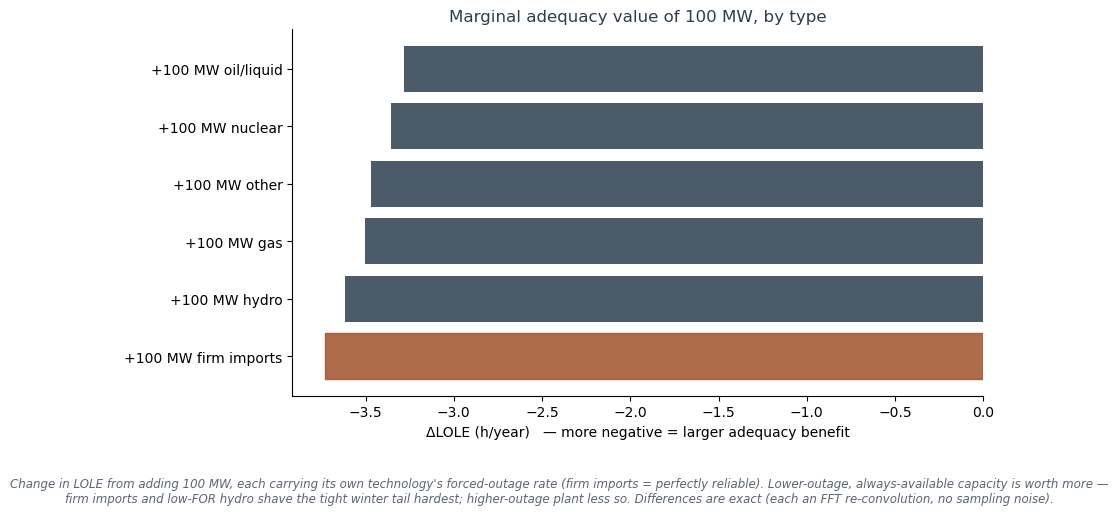

In [37]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 17 · §4 · What moves LOLE — marginal value & sensitivities     v1.1.0
# provides ▸ SENS · MARGINAL
# requires ▸ FLEET · GRID · fft_convolve_units · MW_STEP · avail_cdf · FOR_BY_FUEL
# ══════════════════════════════════════════════════════════════════════════
RUST, INK, GREY = "#A0522D", "#2c3e50", "#5b6472"
raw = GRID["net_load"].to_numpy()
FUEL_NAME = {"NU": "nuclear", "NG": "gas", "WA": "hydro",
             "LF": "oil/liquid", "Other": "other"}

def lole_from_fleet(mw, p_up, extra_firm=0.0):
    pmf = fft_convolve_units(np.asarray(mw), np.asarray(p_up))
    cdf = np.cumsum(pmf); L = len(cdf)
    nl  = np.clip(raw - extra_firm, 0, None)
    k   = np.floor(nl / MW_STEP).astype(int)
    lolp = np.where(k <= 0, 0.0, np.where(k >= L, 1.0, cdf[np.clip(k-1, 0, L-1)]))
    return lolp.sum() * 0.25

mw0, pup0 = FLEET["mw"].to_numpy(), (1 - FLEET["FOR"]).to_numpy()
L0 = lole_from_fleet(mw0, pup0)

# --- marginal value of +100 MW, each at ITS OWN technology's outage rate ---
print("Marginal value — ΔLOLE from +100 MW, each at its own technology's outage rate:")
MARGINAL = {}
for fuel in sorted(FLEET["fuelcode"].unique()):
    p_up_fuel = 1 - FOR_BY_FUEL.get(fuel, 0.07)               # this fuel's availability
    mw1  = np.append(mw0, 100.0); pup1 = np.append(pup0, p_up_fuel)
    MARGINAL[FUEL_NAME.get(fuel, fuel)] = lole_from_fleet(mw1, pup1) - L0
MARGINAL["firm imports"] = lole_from_fleet(mw0, pup0, extra_firm=100.0) - L0   # 100 MW, firm
for name, dL in sorted(MARGINAL.items(), key=lambda kv: kv[1]):
    print(f"   +100 MW {name:12s} : ΔLOLE = {dL:+6.2f} h/year")

# --- sensitivities (elasticities) ------------------------------------------
print("\nSensitivity — % change in LOLE per +1% change in each driver:")
def lole_scaled(scale_load=1.0, scale_avail_gap=1.0):
    global raw; raw_bak = raw
    raw = raw_bak * scale_load
    pup = 1 - (1 - pup0) * scale_avail_gap                    # scale the outage part
    L = lole_from_fleet(mw0, pup); raw = raw_bak
    return L
SENS = {"load (+1%)":         (lole_scaled(scale_load=1.01)/L0 - 1)/0.01,
        "all FORs (+1%)":      (lole_scaled(scale_avail_gap=1.01)/L0 - 1)/0.01,
        "capacity (+1%)":      (lole_from_fleet(mw0*1.01, pup0)/L0 - 1)/0.01}
for k, v in SENS.items():
    print(f"   {k:16s} : elasticity {v:+5.1f}")

# --- figure ----------------------------------------------------------------
items  = sorted(MARGINAL.items(), key=lambda kv: kv[1])       # most benefit first
labels = [f"+100 MW {n}" for n, _ in items]
vals   = [v for _, v in items]
fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.barh(labels, vals, color=INK, alpha=0.85)
bars[0].set_color(RUST)                                        # highlight the best
ax.axvline(0, color="grey", lw=0.7)
for b, v in zip(bars, vals):
    ax.text(v - 0.03, b.get_y()+b.get_height()/2, f"{v:.2f}",
            va="center", ha="right", fontsize=8, color="white")
ax.set_xlabel("ΔLOLE (h/year)   — more negative = larger adequacy benefit")
ax.set_title("Marginal adequacy value of 100 MW, by type", color=INK)
for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.text(0.5, -0.05,
         "Change in LOLE from adding 100 MW, each carrying its own technology's forced-outage rate "
         "(firm imports = perfectly reliable). Lower-outage, always-available capacity is worth more —\n"
         "firm imports and low-FOR hydro shave the tight winter tail hardest; higher-outage plant less "
         "so. Differences are exact (each an FFT re-convolution, no sampling noise).",
         ha="center", va="top", fontsize=8.5, color=GREY, style="italic")
plt.tight_layout(); plt.show()